In [1]:
import os
from math import sqrt
import pickle
import warnings
import time

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as patches
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import xarray as xr
from sklearn.mixture import GaussianMixture
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from utils import read_xarray

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
# Check if CUDA is available and set the device
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

# Load Data

In [3]:
data_type = "CESM"
data_num = "001"

# Read input data
rdir = os.getcwd()
dir_name = rdir + "/data"
chl, mld, sss, sst, u10, xco2, icefrac, patm, pco2 = read_xarray(dir_name, data_type, data_num)

chl = chl.Chl.data[:420, ::-1]
socat_mask = pco2.pCO2_socat.data[:420, ::-1] > 0.5
pco2 = pco2.pCO2.data[:420, ::-1]

# Prepare land mask and SOCAT mask
land_mask = xr.open_dataset(dir_name + "/land.nc").mask.data[::-1]
land_mask = (~np.isnan(land_mask))[np.newaxis, :, :]
land_mask = np.broadcast_to(land_mask, (420, 180, 360))
land_mask = land_mask & (pco2 > 0.5) & (chl > 0)

socat_mask = land_mask & socat_mask

In [4]:
# Load province data
with open('all_provinces.pkl', 'rb') as f:
    all_provinces = pickle.load(f)
land_mask2 = xr.open_dataset(dir_name + "/land.nc").mask.data[::-1]

In [5]:
province15 = np.sum(all_provinces == 15, axis=0)
province15 = province15.astype(float)
province15[np.isnan(land_mask2)] = np.nan

# Figure 1

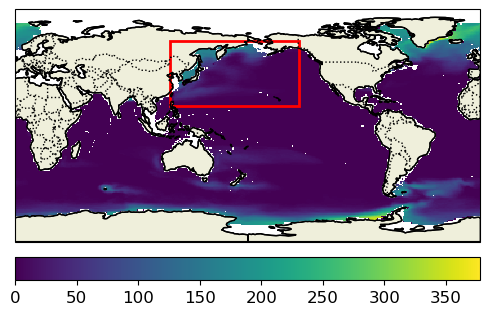

In [6]:
# Define latitude and longitude for plotting
lat = np.linspace(89.5, -89.5, province15.shape[0])
lon = np.linspace(0.5, 359.5, province15.shape[1])

lon, lat = np.meshgrid(lon, lat)

# Plot the province data
fig, ax = plt.subplots(figsize=(6, 4), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
ax.set_global()

c = ax.pcolormesh(lon, lat, province15, transform=ccrs.PlateCarree(), cmap='viridis')

rect = patches.Rectangle((120, 15), 100, 50, linewidth=2, edgecolor='red', facecolor='none',
                         transform=ccrs.PlateCarree())
ax.add_patch(rect)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, edgecolor='black')

cbar = plt.colorbar(c, orientation='horizontal', pad=0.05)
cbar.ax.tick_params(labelsize=12)

plt.savefig('fig/province16_denominator.pdf', format='pdf')

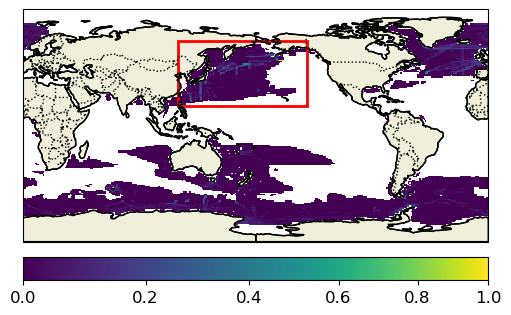

In [7]:
# Plot the observed province data
obv_pro15 = np.sum((all_provinces == 15) & socat_mask, axis=0)
obv_pro15 = obv_pro15.astype(float)
obv_pro15[np.isnan(land_mask2)] = np.nan

obv_pro15_den = obv_pro15 / province15

lat = np.linspace(89.5, -89.5, obv_pro15_den.shape[0])
lon = np.linspace(0.5, 359.5, obv_pro15_den.shape[1])

lon, lat = np.meshgrid(lon, lat)

fig, ax = plt.subplots(figsize=(6, 4), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
ax.set_global()

log_obv_pro15_den = np.log1p(obv_pro15_den)

# Define a custom normalization for the color scale
class LogNorm(mcolors.Normalize):
    def __init__(self, vmin=None, vmax=None, clip=False):
        super().__init__(vmin, vmax, clip)

    def __call__(self, value, clip=None):
        return np.ma.masked_array(np.log1p(value) / np.log1p(self.vmax), mask=np.ma.getmask(value))

norm = LogNorm(vmin=0, vmax=1)
c = ax.pcolormesh(lon, lat, obv_pro15_den, transform=ccrs.PlateCarree(), cmap='viridis', norm=norm)

rect = patches.Rectangle((120, 15), 100, 50, linewidth=2, edgecolor='red', facecolor='none',
                         transform=ccrs.PlateCarree())
ax.add_patch(rect)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, edgecolor='black')

cbar = plt.colorbar(c, orientation='horizontal', pad=0.05)
cbar.ax.tick_params(labelsize=12)

plt.savefig('fig/province16_percentage.pdf', format='pdf')

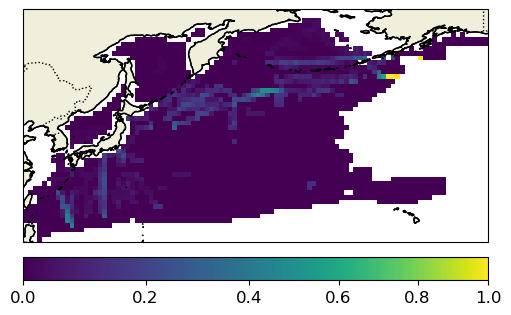

In [8]:
# Plot the observed province data for the North Pacific region
lat = np.linspace(89.5, -89.5, obv_pro15_den.shape[0])
lon = np.linspace(0.5, 359.5, obv_pro15_den.shape[1])

lon, lat = np.meshgrid(lon, lat)

fig, ax = plt.subplots(figsize=(6, 4), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})

ax.set_extent([120, 220, 15, 65], crs=ccrs.PlateCarree())

c = ax.pcolormesh(lon, lat, obv_pro15_den, transform=ccrs.PlateCarree(), cmap='viridis', norm=norm)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, edgecolor='black')

cbar = plt.colorbar(c, orientation='horizontal', pad=0.05)
cbar.ax.tick_params(labelsize=12)

plt.savefig('fig/province16_percentage_north_pacific.pdf', format='pdf')

In [9]:
# Function to format y-axis labels
def log_format(value, tick_number):
    return f'{int(value):,}'

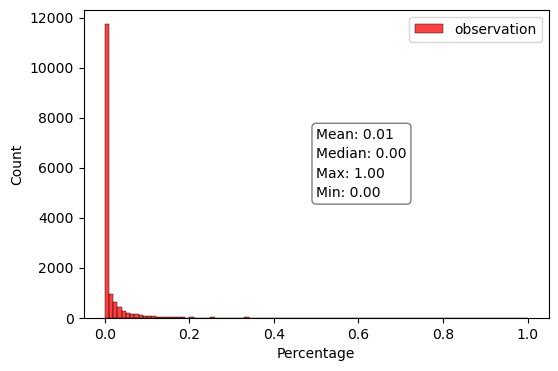

In [10]:
# Calculate statistics for the observed province data
obv_pro15_den_pure = obv_pro15_den[~np.isnan(obv_pro15_den)]
mean_value = np.mean(obv_pro15_den_pure)
median_value = np.median(obv_pro15_den_pure)
max_value = np.max(obv_pro15_den_pure)
min_value = np.min(obv_pro15_den_pure)

# Plot histogram of the observed province data
plt.subplots(figsize=(6, 4))
sns.histplot(obv_pro15_den_pure, bins=100, color="red", label='observation')
plt.xlabel('Percentage')
plt.ylabel('Count')
plt.legend()

textstr = '\n'.join((
    f'Mean: {mean_value:.2f}',
    f'Median: {median_value:.2f}',
    f'Max: {max_value:.2f}',
    f'Min: {min_value:.2f}'
))

props = dict(boxstyle='round', facecolor='white', alpha=0.5)
plt.text(0.5, 0.5, textstr, transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='center', horizontalalignment='left', bbox=props, linespacing=1.5)

plt.savefig('fig/province16_hist.pdf', format='pdf')

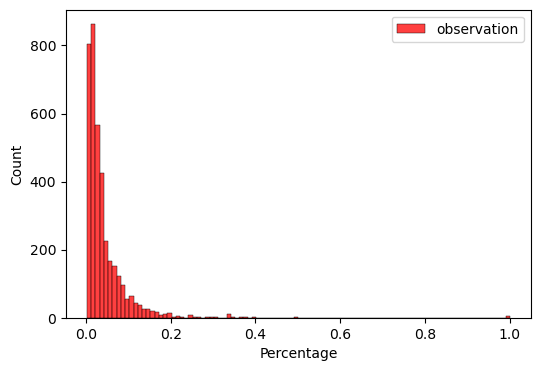

In [11]:
# Calculate statistics for the observed province data without zero
obv_pro15_den_nonzero = obv_pro15_den_pure[obv_pro15_den_pure != 0]
# Plot histogram of the observed province data
plt.subplots(figsize=(6, 4))
sns.histplot(obv_pro15_den_nonzero, bins=100, color="red", label='observation')
plt.xlabel('Percentage')
plt.ylabel('Count')
plt.legend()

plt.savefig('fig/province16_hist_nonzero.pdf', format='pdf')

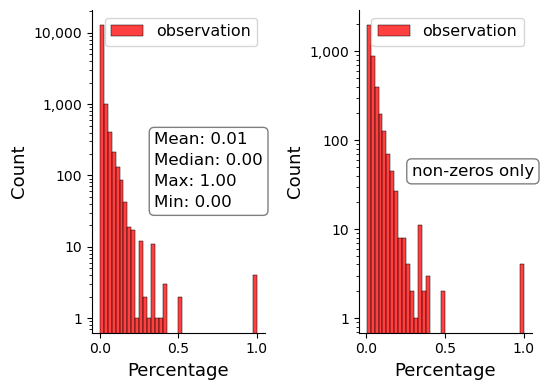

In [12]:
# Plot 2 histograms together
fig, axs = plt.subplots(1, 2, figsize=(6, 4))

deep_red = (0.3, 0, 0)

sns.histplot(obv_pro15_den_pure, bins=40, color='red', label='observation', ax=axs[0])
axs[0].set_xlabel('Percentage', fontsize=13)
axs[0].set_ylabel('Count', fontsize=13)
axs[0].set_yscale('log')
axs[0].legend(prop={'size': 11.5})
axs[0].get_yaxis().set_major_formatter(FuncFormatter(log_format))

textstr = '\n'.join((
    f'Mean: {mean_value:.2f}',
    f'Median: {median_value:.2f}',
    f'Max: {max_value:.2f}',
    f'Min: {min_value:.2f}'
))

props = dict(boxstyle='round', facecolor='white', alpha=0.5)
axs[0].text(0.36, 0.5, textstr, transform=axs[0].transAxes, fontsize=12,
            verticalalignment='center', horizontalalignment='left', bbox=props, linespacing=1.5)

# Hide unnecessary plot spines
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[0].spines['left'].set_visible(True)
axs[0].spines['bottom'].set_visible(True)

# the second plot
sns.histplot(obv_pro15_den_nonzero, bins=40, color='red', label='observation', ax=axs[1])
axs[1].set_xlabel('Percentage', fontsize=13)
axs[1].set_ylabel('Count', fontsize=13)
axs[1].set_yscale('log')
axs[1].legend(prop={'size': 11.5})
axs[1].get_yaxis().set_major_formatter(FuncFormatter(log_format))

textstr = "non-zeros only"
axs[1].text(1.85, 0.5, textstr, transform=axs[0].transAxes, fontsize=12,
            verticalalignment='center', horizontalalignment='left', bbox=props, linespacing=1.5)

# Hide unnecessary plot spines
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
axs[1].spines['left'].set_visible(True)
axs[1].spines['bottom'].set_visible(True)

plt.tight_layout()
plt.savefig('fig/province16_hist_com.pdf', format='pdf')

# Figure 5-(A) & S1

In [13]:
# Read CESM 002 data
chl_CESM002, mld_CESM002, sss_CESM002, sst_CESM002, u10_CESM002, xco2_CESM002, icefrac_CESM002, patm_CESM002, \
pco2_CESM002 = read_xarray(dir_name, 'CESM', '002')
pco2_CESM002 = pco2_CESM002.pCO2.data[:420, ::-1]
with open('all_provinces_CESM002.pkl', 'rb') as f:
    all_provinces_CESM002 = pickle.load(f)

In [14]:
province = 15
month_name = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

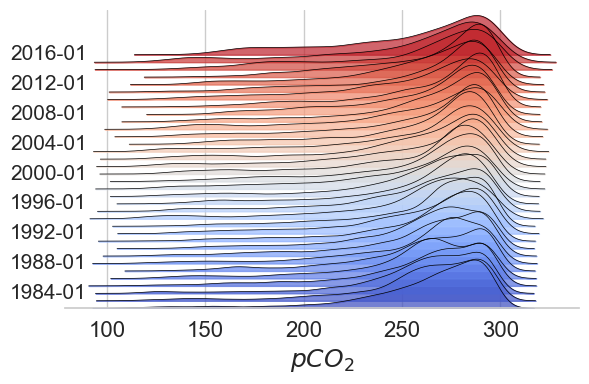

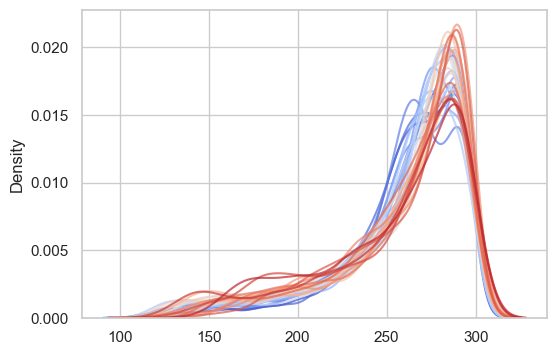

In [15]:
# Loop through each month to create density plots
for month in range(12):
    sns.set(style="whitegrid")  # Set Seaborn plot style to whitegrid

    fig, ax = plt.subplots(figsize=(6, 4))  # Create a new figure and axis

    cmap = plt.get_cmap('coolwarm')  # Get the 'coolwarm' colormap
    num_months = 35  # Number of months to plot
    colors = [cmap(i / num_months) for i in range(num_months)]  # Generate a list of colors
    plt.subplots(figsize=(6, 4))  # Create a new subplot

    shift = 0.3  # Vertical shift for KDE plots
    text_x_position = 300  # Initial x position for text annotations

    # Loop through each month's data
    for month_idx in range(num_months):
        # Get pCO2 data for the current month and province
        data = pco2_CESM002[month + 12 * month_idx][
            land_mask[month + 12 * month_idx] & (all_provinces_CESM002[month + 12 * month_idx] == province)
        ]

        if data.size > 0:  # If there is data for the current month
            # Plot KDE for the current month's data
            kde = sns.kdeplot(data, fill=False, color=colors[month_idx], alpha=0.7, linewidth=1.5)
            kde_data = kde.get_lines()[-1].get_data()  # Get KDE line data
            kde_data_x = kde_data[0]  # X values of KDE
            kde_data_y = None  # Y values of KDE (to be determined below)

            # Adjust y values based on the current month
            if month in [3, 5, 6]:
                kde_data_y = 90 * kde_data[1] + month_idx * shift
            elif month in [4, 8, 7]:
                kde_data_y = 50 * kde_data[1] + month_idx * shift
            elif month == 10:
                kde_data_y = 20 * kde_data[1] + month_idx * shift
            elif month == 9:
                kde_data_y = 15 * kde_data[1] + month_idx * shift
            elif month == 11:
                kde_data_y = 80 * kde_data[1] + month_idx * shift
            else:
                kde_data_y = 100 * kde_data[1] + month_idx * shift

            # Fill the area under the KDE curve
            ax.fill_between(kde_data_x, kde_data_y, month_idx * shift, color=colors[month_idx], alpha=0.7)
            ax.plot(kde_data_x, kde_data_y, color='black', linewidth=0.5)  # Plot the KDE line

            year = 1982 + month_idx  # Calculate the year for the current month

            # Adjust text position if necessary
            if kde_data_x.min() - 40 < text_x_position:
                text_x_position = kde_data_x.min() - 40

    # Annotate the plot with year labels
    for year in range(1984, 2020, 4):
        ax.text(text_x_position, (year - 1982) * shift, f'{year}-{(month + 1):02d}', verticalalignment='center',
                fontsize=15)

    ax.set_ylim(0, (num_months + 5) * shift)  # Set y-axis limits
    ax.set_yticks([])  # Remove y-axis ticks
    ax.set_xlabel(r'$pCO_2$', fontsize=18)  # Set x-axis label
    ax.tick_params(axis='x', labelsize=16)

    # Hide unnecessary plot spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(True)

    fig.tight_layout()  # Adjust the layout

    # Save the figure to a file
    fig.savefig(f'fig/month_density/province16_{month_name[month]}_density.pdf', format='pdf')

    if month == 0:
        plt.show()

    plt.close('all')  # Close the figure to free up memory

# Figure

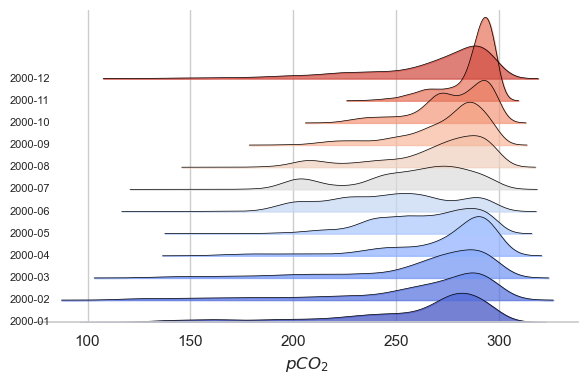

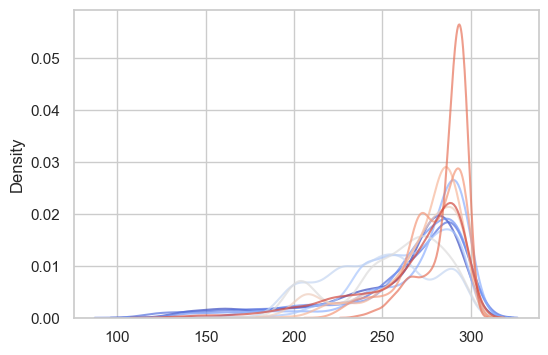

In [16]:
# Loop through each year to create density plots
for year in range(1982, 2017):
    sns.set(style="whitegrid")  # Set Seaborn plot style to whitegrid

    fig, ax = plt.subplots(figsize=(6, 4))  # Create a new figure and axis

    cmap = plt.get_cmap('coolwarm')  # Get the 'coolwarm' colormap
    num_months = 12  # Number of months in a year
    colors = [cmap(i / num_months) for i in range(num_months)]  # Generate a list of colors
    plt.subplots(figsize=(6, 4))  # Create a new subplot

    shift = 0.3  # Vertical shift for KDE plots
    text_x_position = 300  # Initial x position for text annotations
    max_y_value = 0  # Variable to store the maximum y value for setting y-axis limit

    # Loop through each month in the year
    for month in range(12):
        # Get pCO2 data for the current month and province
        data = pco2_CESM002[month + 12 * (year - 1982)][
            land_mask[month + 12 * (year - 1982)] & (all_provinces_CESM002[month + 12 * (year - 1982)] == province)
        ]

        if data.size > 0:  # If there is data for the current month
            # Plot KDE for the current month's data
            kde = sns.kdeplot(data, fill=False, color=colors[month], alpha=0.7, linewidth=1.5)
            kde_data = kde.get_lines()[-1].get_data()  # Get KDE line data
            kde_data_x = kde_data[0]  # X values of KDE
            kde_data_y = 20 * kde_data[1] + month * shift  # Adjust y values based on the current month

            # Fill the area under the KDE curve
            ax.fill_between(kde_data_x, kde_data_y, month * shift, color=colors[month], alpha=0.7)
            ax.plot(kde_data_x, kde_data_y, color='black', linewidth=0.5)  # Plot the KDE line

            # Adjust text position if necessary
            if kde_data_x.min() - 25 < text_x_position:
                text_x_position = kde_data_x.min() - 25

            # Update the maximum y value
            if kde_data_y.max() > max_y_value:
                max_y_value = kde_data_y.max()

    # Annotate the plot with month labels
    for month in range(12):
        ax.text(text_x_position, month * shift, f'{year}-{(month + 1):02d}', verticalalignment='center', fontsize=8)

    ax.set_ylim(0, max_y_value + shift / 3)  # Set y-axis limits
    ax.set_yticks([])  # Remove y-axis ticks
    ax.set_xlabel(r'$pCO_2$')  # Set x-axis label

    # Hide unnecessary plot spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(True)

    fig.tight_layout()  # Adjust the layout

    # Save the figure to a file
    fig.savefig(f'fig/year_density/province16_{year}_density.pdf', format='pdf')
    if year == 2000:
        plt.show()

    plt.close('all')  # Close the figure to free up memory

In [17]:
# Load raw predictions
with open('raw_y_hat.pkl', 'rb') as f:
    raw_y_hat = pickle.load(f)

# Kernelized Stein Discrepancy
$$u_q(x, x') := s_q(x) k(x, x') s_q(x') + s_q(x) \nabla_{x'} k(x, x') + s_q(x')  \nabla_{x} k(x,x') +  \nabla_{x,x'} k(x,x')$$

$$k(x,x') = \exp(\dfrac{-(x_1-x_2)^2}{2h})$$

$$s_q(x) = - \sum_{k=1}^K \dfrac{\pi_k \mathcal{N}(x|\mu_k, \sigma_k^2)}{q(x)} \cdot \dfrac{x-\mu_k}{\sigma_k^2} = - \dfrac{\sum_{k=1}^K \pi_k \exp(\dfrac{-(x-\mu_k)^2}{2 \sigma_k^2}) \cdot \dfrac{x-\mu_k}{\sigma_k^2}  }{\sum_{k=1}^K \pi_k \exp(\dfrac{-(x-\mu_k)^2}{2 \sigma_k^2})}$$

In [18]:
def u_q(x_1, x_2, mu, var, pi, h):
    # Compute log probabilities and weights for GMM components
    log_probs = torch.log(pi) - 0.5 * torch.log(var) - (x_1 - mu) ** 2 / 2 / var
    log_weights1 = torch.log(x_1) - torch.log(var)
    log_weights2 = torch.log(mu) - torch.log(var)
    log_sum_weights1 = torch.logsumexp(log_probs + log_weights1, dim=1, keepdim=True)
    log_sum_weights2 = torch.logsumexp(log_probs + log_weights2, dim=1, keepdim=True)
    log_sum_probs = torch.logsumexp(log_probs, dim=1, keepdim=True)
    sq1 = torch.exp(log_sum_weights1 - log_sum_probs) - torch.exp(log_sum_weights2 - log_sum_probs)

    # Compute log probabilities and weights for the second input
    log_probs = (torch.log(pi) - 0.5 * torch.log(var)).unsqueeze(1) - (x_2 - mu.unsqueeze(1)) ** 2 / 2 / var.unsqueeze(1)
    log_weights1 = torch.log(x_2) - torch.log(var).unsqueeze(1)
    log_weights2 = (torch.log(mu) - torch.log(var)).unsqueeze(1)
    log_sum_weights1 = torch.logsumexp(log_probs + log_weights1, dim=0, keepdim=True)
    log_sum_weights2 = torch.logsumexp(log_probs + log_weights2, dim=0, keepdim=True)
    log_sum_probs = torch.logsumexp(log_probs, dim=0, keepdim=True)
    sq2 = torch.exp(log_sum_weights1 - log_sum_probs) - torch.exp(log_sum_weights2 - log_sum_probs)

    # Compute the final result based on bandwidth h
    if h == float('inf'):
        return sq1 * sq2
    else:
        return torch.exp(-(x_1 - x_2) ** 2 / 2 / (h ** 2)) * (
                    sq1 * sq2 - (sq1 - sq2) * (x_1 - x_2) / h ** 2 + 1 / h ** 2 - (x_1 - x_2) ** 2 / h ** 4)

In [19]:
def u_q_pairwise_sum_parallel(x_1: torch.Tensor, mu: torch.Tensor, sigma: torch.Tensor, pi: torch.Tensor, h: float, batch_size: int = 3000) -> torch.Tensor:
    n = x_1.shape[0]
    final_sum = 0.0

    # Compute pairwise sums in parallel batches
    for start_i in range(0, n, batch_size):
        end_i = min(start_i + batch_size, n)
        batch_sum = 0.0

        for start_j in range(0, n, batch_size):
            end_j = min(start_j + batch_size, n)
            block_i = x_1[start_i:end_i]
            block_j = x_1[start_j:end_j]

            results = u_q(block_i, block_j.reshape(1, -1), mu, sigma, pi, h)

            # Zero out diagonal elements for the same block
            if start_i == start_j:
                results.fill_diagonal_(0)

            batch_sum += torch.sum(results)

        final_sum += batch_sum

    return final_sum / sqrt(n)

# Main Algorithm

In [20]:
start = time.time()

In [21]:
# Initialize parameters for the second calibration
province = 15
batch_size = 3000
n_components = 15
is_standardize = True
is_print = False
bounds = {0: (350, 950), 1: (300, 400), 2: (300, 400), 3: (300, 400), 4: (300, 400), 5: (300, 400),
          6: (300, 400), 7: (300, 400), 8: (300, 400), 9: (300, 400), 10: (300, 400), 11: (250, 350),
          12: (300, 400), 13: (300, 400), 14: (250, 350), 15: (50, 350), }


total_raw_SE = 0
total_opt_SE = 0
total_stan_SE = 0
total_raw_WDL = 0
total_opt_WDL = 0
total_stan_WDL = 0
total_n = 0


raw_SE_LOOs = np.zeros((12, 7))
opt_SE_LOOs = np.zeros((12, 7))
stan_SE_LOOs = np.zeros((12, 7))
raw_WDL_LOOs = np.zeros((12, 7))
opt_WDL_LOOs = np.zeros((12, 7))
stan_WDL_LOOs = np.zeros((12, 7))
number_LOOs = np.zeros((12, 7))

In [22]:
def calibration(pco2_ref, all_provinces_ref, month, province, batch_size, n_components, is_standardize=True, lamb=0.01,
                max_step=201, tolerance=20, bandwidth=3, draw_plot=False):
    months = list(range(month + 336, 420, 12))

    # Prepare training data based on the reference month and province
    train_y = pco2_ref[months][land_mask[months] & (all_provinces_ref[months] == province)]

    # Fit Gaussian Mixture Model (GMM) to the training data
    gmm = GaussianMixture(n_components=n_components, random_state=42)
    gmm.fit(train_y.reshape(-1, 1))

    # Extract GMM parameters
    means = torch.tensor(gmm.means_.flatten(), dtype=torch.float64, device=device)
    weights = torch.tensor(gmm.weights_.flatten(), dtype=torch.float64, device=device)
    covariances = torch.tensor(gmm.covariances_.flatten(), dtype=torch.float64, device=device)
    overall_mean = torch.dot(weights, means)
    overall_std = torch.sqrt(torch.dot(weights, means ** 2 + covariances) - overall_mean ** 2)

    # Prepare test data based on the reference month and province
    test_y = pco2[months][land_mask[months] & (all_provinces[months] == province)]
    y_test_hat = raw_y_hat[months][land_mask[months] & (all_provinces[months] == province)]


    # Calculate the number of data points in each month
    number_monthly = np.array(
        [np.sum(land_mask[months[i]] & (all_provinces[months[i]] == province)) for i in range(7)])

    # Normalize the test predictions
    y_test_hat_tensor = torch.tensor(y_test_hat, dtype=torch.float64, device=device)
    if is_standardize:
        y_test_hat_tensor = torch.clip((y_test_hat_tensor - torch.mean(y_test_hat_tensor)) / torch.std(
            y_test_hat_tensor) * overall_std + overall_mean, bounds[province][0], bounds[province][1])
    else:
        y_test_hat_tensor = torch.clip(y_test_hat_tensor, bounds[province][0], bounds[province][1])
    y_test_hat_tensor = y_test_hat_tensor.clone().detach().requires_grad_(True)
    y_test_hat_tensor_numpy = y_test_hat_tensor.detach().cpu().clone().numpy()

    with torch.no_grad():
        h = bandwidth * torch.std(y_test_hat_tensor).item()

    # Pre-calculate GMM quantiles for dist_WDL
    q_vec = torch.arange(1, 1000, dtype=torch.float64) / 1000
    gmm_quantiles = np.percentile(gmm.sample(10000)[0], q_vec * 100)

    # Early stopping setup
    best_results = {'dist_wdl': np.sum((np.quantile(y_test_hat_tensor_numpy, q_vec) - gmm_quantiles) ** 2),
                    'best_test_y_hat': y_test_hat_tensor_numpy}
    early_stopping_patience = 0

    n_test = len(y_test_hat_tensor)

    # Perform gradient descent with early stopping based on dist_WDL
    for step in range(max_step):
        KSD = 0

        # Compute pairwise discrepancies and gradients (this is where KSD is calculated through u_q)
        for start_i in range(0, n_test, batch_size):
            end_i = min(start_i + batch_size, n_test)
            for start_j in range(0, n_test, batch_size):
                end_j = min(start_j + batch_size, n_test)

                result = u_q(y_test_hat_tensor[start_i:end_i].unsqueeze(1),
                             y_test_hat_tensor[start_j:end_j].unsqueeze(0),
                             means, covariances, weights, h)
                if start_i == start_j:
                    result.fill_diagonal_(0)
                sum_result = torch.sum(result) / np.sqrt(n_test)
                sum_result.backward()
                with torch.no_grad():
                    KSD += sum_result

        # Clip gradients
        gradient = y_test_hat_tensor.grad
        gradient = torch.clip(gradient, -5 * torch.median(torch.abs(gradient)), 5 * torch.median(torch.abs(gradient)))

        with torch.no_grad():
            gradient /= torch.sqrt(torch.mean(gradient ** 2)) / torch.std(y_test_hat_tensor)

            # Adjust predictions to minimize discrepancy
            y_test_hat_tensor -= lamb * gradient

        y_test_hat_tensor.grad.zero_()  # Reset gradients

        # Calculate dist_WDL (Wasserstein distance between y_test_hat and GMM quantiles)
        y_test_hat_numpy = y_test_hat_tensor.detach().cpu().clone().numpy()
        dist_WDL = np.sum((np.quantile(y_test_hat_numpy, q_vec) - gmm_quantiles) ** 2)


        # Early stopping logic
        if dist_WDL < best_results['dist_wdl']:  # Update the best results if improvement
            best_results = {
                'dist_wdl': dist_WDL,
                'best_test_y_hat': y_test_hat_numpy
            }
            early_stopping_patience = 0  # Reset patience if there's improvement
        else:
            early_stopping_patience += 1  # Increment patience if no improvement

        # Trigger early stopping if no improvement for 'tol' steps
        if early_stopping_patience >= tolerance:
            # print(f"Early stopping at step {step} for tolerance {tolerance} due to no improvement in dist_WDL.")
            break

    y_test_opt = best_results['best_test_y_hat']
    # Plot the results if requested
    if draw_plot:
        cmap = plt.get_cmap('coolwarm')
        colors = [cmap((3 - i) / 3) for i in range(4)]
        plt.subplots(figsize=(6, 4))

        if month <= 1 or month == 5:
            breaks = torch.arange(120, 321, 10)
            plt.xlim(105, 335)
            x = np.linspace(120, 320, 3000)
        elif month == 2:
            breaks = torch.arange(140, 321, 9)
            plt.xlim(125, 335)
            x = np.linspace(140, 320, 3000)
        elif month == 3:
            breaks = torch.arange(180, 314, 7)
            plt.xlim(165, 328)
            x = np.linspace(180, 313, 3000)
        elif month == 4:
            breaks = torch.arange(160, 321, 8)
            plt.xlim(145, 335)
            x = np.linspace(160, 320, 3000)
        elif month == 6:
            breaks = torch.arange(149, 321, 9)
            plt.xlim(134, 335)
            x = np.linspace(149, 320, 3000)
        elif month == 7:
            breaks = torch.arange(168, 321, 8)
            plt.xlim(160, 335)
            x = np.linspace(160, 320, 3000)
        elif month == 8:
            breaks = torch.arange(206, 321, 6)
            plt.xlim(195, 330)
            x = np.linspace(206, 320, 3000)
        elif month == 9:
            breaks = torch.arange(206, 307, 5)
            plt.xlim(195, 317)
            x = np.linspace(206, 306, 3000)
        elif month == 10:
            breaks = torch.arange(190, 305, 6)
            plt.xlim(180, 314)
            x = np.linspace(190, 304, 3000)
        elif month == 11:
            breaks = torch.arange(130, 311, 9)
            plt.xlim(115, 325)
            x = np.linspace(130, 310, 3000)
        else:
            raise ValueError("Invalid month")


        sns.histplot(test_y, bins=breaks, stat="density", color=colors[0], label=r"Actual $pCO_2$", alpha=0.5)
        sns.histplot(y_test_opt, bins=breaks, stat="density", color=colors[1], alpha=0.5,
                     label=r"Calibrated $pCO_2$")
        sns.histplot(y_test_hat, bins=breaks, stat="density", color=colors[3], alpha=0.5, label=r"Raw Predicted $pCO_2$")


        log_prob = gmm.score_samples(x.reshape(-1, 1))
        pdf = np.exp(log_prob)
        plt.plot(x, pdf, color='y', label='Knowledge PDF')

        plt.xlabel(r"$pCO_2$", fontsize=18)
        plt.xticks(fontsize=16)
        plt.ylabel('Density', fontsize=18)
        plt.yticks(fontsize=16)
        plt.tight_layout()
        plt.legend(prop={'size': 12.5})
        plt.savefig(f'fig/pco2_calibration/province{province + 1}_{month_name[month]}_calibration.pdf', format='pdf')
        if month == 6:
            plt.show()
        plt.close('all')

    # Calculate squared errors
    raw_SE = np.sum((y_test_hat - test_y) ** 2)
    opt_SE = np.sum((y_test_opt - test_y) ** 2)
    stan_SE = np.sum((y_test_hat_tensor_numpy - test_y) ** 2)

    # Calculate Wasserstein distance
    n_levs = 1000
    q_vec = torch.arange(1, n_levs, dtype=torch.float64) / n_levs

    true_y_quantile = np.quantile(test_y, q_vec)
    y_test_hat_quantile = np.quantile(y_test_hat, q_vec)
    y_test_opt_quantile = np.quantile(y_test_opt, q_vec)
    y_test_stan_quantile = np.quantile(y_test_hat_tensor_numpy, q_vec)

    raw_WDL = np.mean((true_y_quantile - y_test_hat_quantile) ** 2)
    opt_WDL = np.mean((true_y_quantile - y_test_opt_quantile) ** 2)
    stan_WDL = np.mean((true_y_quantile - y_test_stan_quantile) ** 2)


    # Calculate LOO squared erros and Wasserstein distance
    raw_SE_LOO = np.zeros(7)
    opt_SE_LOO = np.zeros(7)
    stan_SE_LOO = np.zeros(7)
    raw_WDL_LOO = np.zeros(7)
    opt_WDL_LOO = np.zeros(7)
    stan_WDL_LOO = np.zeros(7)
    idx = np.insert(np.cumsum(number_monthly), 0, 0)
    for i in range(7):
        start_idx = idx[i]
        end_idx = idx[i + 1]

        mask = np.ones(len(test_y), dtype=bool)
        mask[start_idx:end_idx] = False

        test_y_excluded = test_y[mask]
        y_test_hat_excluded = y_test_hat[mask]
        y_test_opt_excluded = y_test_opt[mask]
        y_test_stan_excluded = y_test_hat_tensor_numpy[mask]

        raw_SE_LOO[i] = np.sum((y_test_hat_excluded - test_y_excluded) ** 2)
        opt_SE_LOO[i] = np.sum((y_test_opt_excluded - test_y_excluded) ** 2)
        stan_SE_LOO[i] = np.sum((y_test_stan_excluded - test_y_excluded) ** 2)

        true_y_excluded_quantile = np.quantile(test_y_excluded, q_vec)
        y_test_hat_excluded_quantile = np.quantile(y_test_hat_excluded, q_vec)
        y_test_opt_excluded_quantile = np.quantile(y_test_opt_excluded, q_vec)
        y_test_stan_excluded_quantile = np.quantile(y_test_stan_excluded, q_vec)

        raw_WDL_LOO[i] = np.mean((true_y_excluded_quantile - y_test_hat_excluded_quantile) ** 2)
        opt_WDL_LOO[i] = np.mean((true_y_excluded_quantile - y_test_opt_excluded_quantile) ** 2)
        stan_WDL_LOO[i] = np.mean((true_y_excluded_quantile - y_test_stan_excluded_quantile) ** 2)


    return raw_SE, opt_SE, stan_SE, raw_WDL, opt_WDL, stan_WDL, n_test, np.sum(
        socat_mask[months] & (all_provinces_ref[months] == province)), raw_SE_LOO, opt_SE_LOO, \
           stan_SE_LOO, raw_WDL_LOO, opt_WDL_LOO, stan_WDL_LOO, number_monthly

# Table 2, 3, S5, S6, S7, S8 & Figure 5-(B), S2

Jan 14146 863 989.8537534604295 727.0862461762919 847.1752199406868 362.5306237919562 121.04528050420437 145.08114315375815 990.074066797587 727.3421587715501 847.377946604217 363.4047133474916 121.72397964022241 146.07697987754358 28.03001213199019 22.438319493101016 26.507072208219757 10.863282299518591 16.760240035326348 14.57083621148285
Feb 8462 408 646.2919212729068 628.1722314397662 677.2558217205674 170.67037142587546 91.75229745518446 106.1982605039067 646.6532470855384 628.4877749969528 677.5742477468673 172.01783604304634 93.22038718938322 107.70061506825057 26.61210491501379 26.634689502459292 28.297057568828766 20.707421711374923 14.62893756246238 13.062588956027811
Mar 5313 194 613.4652577135821 618.1117768054348 655.7351652245845 158.1968243452107 101.31658106116147 125.59623837051386 613.7264412765652 618.3838664261062 655.997565771082 159.19540991531625 102.4500273686839 126.68619961924709 22.08590926121396 23.365771116765952 22.46465564868951 9.819335695303117 8.74611

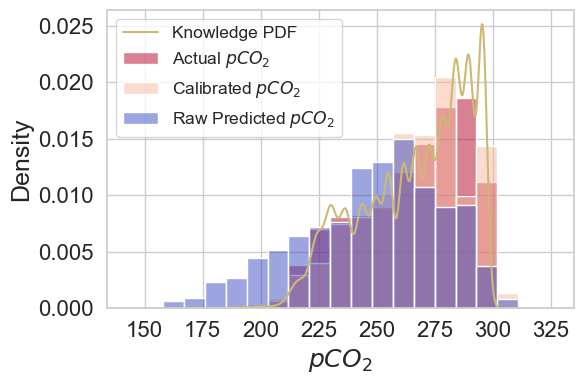

Jul 8725 631 894.2863418161619 383.2421291931872 391.43238406461506 378.4868629174896 7.216931211221276 8.710335086017764 894.966160476102 383.5354819186311 391.70850129524666 379.2758553322706 7.81553422282307 9.322728714420432 44.46622382636579 16.73025404435577 16.23970566372266 31.630956002294866 0.6308788696849315 0.8764204941192182
Aug 5095 268 924.4799843903289 247.18925410914332 274.5355486527121 557.8745274753941 13.355240944437307 25.751403809813898 925.3192025205292 247.3907859963461 274.7127310432451 559.6196691143676 13.938137593738029 26.380998214039398 51.82251388003205 11.532158489526863 10.541048658853187 39.20846885601085 1.8291241522686794 1.745876453841118
Sep 3615 60 936.5557280830479 250.31677690900227 265.0712508426043 542.6958553933534 43.813737642359946 45.94768991937137 937.818712499488 250.65389910909607 265.3961365532795 543.1403036359665 43.93759531764296 46.09629510451445 49.83367705416496 14.277069747503427 14.23513405750936 27.941830144909062 4.164809786

In [23]:
# Perform calibration for each month
for month in range(12):
    raw_SE, opt_SE, stan_SE, raw_WDL, opt_WDL, stan_WDL, n_test, n_obv, raw_SE_LOO,\
    opt_SE_LOO, stan_SE_LOO, raw_WDL_LOO, opt_WDL_LOO, stan_WDL_LOO,\
    number_monthly = calibration(
        pco2_CESM002, all_provinces_CESM002, month, province, batch_size, n_components, draw_plot=True)
    number_LOO = np.sum(number_monthly) * np.ones(7) - number_monthly
    print(month_name[month], n_test, n_obv, raw_SE / n_test, opt_SE / n_test, stan_SE / n_test,
          raw_WDL, opt_WDL, stan_WDL,
          np.mean(raw_SE_LOO / number_LOO), np.mean(opt_SE_LOO / number_LOO),
          np.mean(stan_SE_LOO / number_LOO),
          np.mean(raw_WDL_LOO), np.mean(opt_WDL_LOO), np.mean(stan_WDL_LOO),
          np.std(raw_SE_LOO / number_LOO), np.std(opt_SE_LOO / number_LOO),
          np.std(stan_SE_LOO / number_LOO),
          np.std(raw_WDL_LOO), np.std(opt_WDL_LOO), np.std(stan_WDL_LOO))

    total_raw_SE += raw_SE
    total_opt_SE += opt_SE
    total_stan_SE += stan_SE
    total_raw_WDL += raw_WDL * n_test
    total_opt_WDL += opt_WDL * n_test
    total_stan_WDL += stan_WDL * n_test
    total_n += n_test

    raw_SE_LOOs[month] = raw_SE_LOO
    opt_SE_LOOs[month] = opt_SE_LOO
    stan_SE_LOOs[month] = stan_SE_LOO
    raw_WDL_LOOs[month] = raw_WDL_LOO * number_LOO
    opt_WDL_LOOs[month] = opt_WDL_LOO * number_LOO
    stan_WDL_LOOs[month] = stan_WDL_LOO * number_LOO

    number_LOOs[month] = number_LOO

In [24]:
# Print overall results
print('raw MSE:', total_raw_SE / total_n)
print('opt MSE:', total_opt_SE / total_n)
print('stan MSE:', total_stan_SE / total_n)
print('raw WDL:', total_raw_WDL / total_n)
print('opt WDL:', total_opt_WDL / total_n)
print('stan WDL:', total_stan_WDL / total_n)

raw_MSE_LOO = np.sum(raw_SE_LOOs, axis=0) / np.sum(number_LOOs, axis=0)
opt_MSE_LOO = np.sum(opt_SE_LOOs, axis=0) / np.sum(number_LOOs, axis=0)
stan_MSE_LOO = np.sum(stan_SE_LOOs, axis=0) / np.sum(number_LOOs, axis=0)
raw_WDL_LOO = np.sum(raw_WDL_LOOs, axis=0) / np.sum(number_LOOs, axis=0)
opt_WDL_LOO = np.sum(opt_WDL_LOOs, axis=0) / np.sum(number_LOOs, axis=0)
stan_WDL_LOO = np.sum(stan_WDL_LOOs, axis=0) / np.sum(number_LOOs, axis=0)

print('LOO raw MSE:', np.mean(raw_MSE_LOO))
print('LOO opt MSE:', np.mean(opt_MSE_LOO))
print('LOO stan MSE:', np.mean(stan_MSE_LOO))
print('LOO raw WDL:', np.mean(raw_WDL_LOO))
print('LOO opt WDL:', np.mean(opt_WDL_LOO))
print('LOO stan WDL:', np.mean(stan_WDL_LOO))

print('LOO raw MSE std:', np.std(raw_MSE_LOO))
print('LOO opt MSE std:', np.std(opt_MSE_LOO))
print('LOO stan MSE std:', np.std(stan_MSE_LOO))
print('LOO raw WDL std:', np.std(raw_WDL_LOO))
print('LOO opt WDL std:', np.std(opt_WDL_LOO))
print('LOO stan WDL std:', np.std(stan_WDL_LOO))

raw MSE: 1177.50742462198
opt MSE: 586.4380243097166
stan MSE: 637.55126532554
raw WDL: 574.4285607603998
opt WDL: 67.01485932994999
stan WDL: 81.68323948912413
LOO raw MSE: 1177.902219705617
LOO opt MSE: 586.6528724284619
LOO stan MSE: 637.7734134169077
LOO raw WDL: 575.2984999130006
LOO opt WDL: 67.86670631963855
LOO stan WDL: 82.5789678983126
LOO raw MSE std: 29.322641216666437
LOO opt MSE std: 15.889068503751888
LOO stan MSE std: 17.04105753041278
LOO raw WDL std: 17.730964717572032
LOO opt WDL std: 4.811642024492451
LOO stan WDL std: 4.845435247603542


In [25]:
print('time:', time.time() - start)

time: 54.95987153053284
